# README

Este código es copia EXACTA de lo que existía en **1. EDA** al final como el primer modelo de ML no supervisado (kmeans) que se implementó, se movió aquí aunque hace falta hacerle las modificaciones. Se movió con la inteción de limpiar la libreta 1. EDA para dejar unicamente la ingeniería de características en la anterior libreta. 

Este modelo de kmeans es de Christian

# Modelo de clustering

El objetivo del proceso de clustering será identificar patrones en consumo de compomenentes nutricionales y realizar el diagnóstico de cada cluster con base en cada componente del DQI-I, para finalmente realizar recomendaciones a nivel de cluster de cómo podrían mejorar su dieta para mejorar la calidad de su dieta.

## Preparación de los datos

In [ ]:
df_nutrients.columns

NameError: name 'df_nutrients' is not defined

Crea un archivo csv con los datos de df_nutrients

In [ ]:
df_nutrients.to_csv('df_nutrients_models.csv', index=False, mode='w')

Eliminamos las columnas con los valores del DQI, dado que precisamente queremos analizar el resultado del clustering contra estos valores.

In [ ]:
df_clustering = df_nutrients.copy()
df_clustering = df_clustering.drop(columns=['empty_calories_dqi', 'grasa_dqi', 'fa_sat_dqi', 'colesterol_dqi',
                                             'moderation_dqi', 'balance_dqi', 'fatty_acids_dqi', 'macronutrients_dqi'])

Combinamos los datos de los componentes nutricionales con la información demográfica de cada persona. Los datos antropométricos los dejaremos por fuera del proceso de clustering, dado que también analizaremos los clusters de patrones de alimentación contra estos datos para identificar que clusters son más saludables que otros desde sus variables antropométicas.

In [ ]:
df_clustering = df_clustering.merge(df_dem_final, left_on='folio_integrante', right_on='folio_integrante', how='left')
df_clustering.isnull().sum().sort_values(ascending=False).head(10)

folio_integrante    0
energ_kcal          0
fa_mono             0
fa_poly             0
chole               0
carbohydrt_ratio    0
lipid_tot_ratio     0
protein_ratio       0
poly_ratio          0
mono_ratio          0
dtype: int64

Eliminamos de la muestra las personas que no tuvieron una entrevista 100% y dejamos únicamente los altos entre 18 y 60 años

In [ ]:
df_clustering = df_clustering[(df_clustering['resultado_general_entrevista'] == 1) & (df_clustering['edad'] <= 60) & (df_clustering['edad'] >= 18)]
df_clustering = df_clustering.drop(columns=['resultado_general_entrevista'])
df_clustering.shape

(599, 47)

También, dejaremos por fuera del análisis a las personas que presentaron novedades con las encuetas de datos antropométricos, dado que estas variables también harán parde del análisis posterior.

In [ ]:
df_clustering = df_clustering[df_clustering['folio_integrante'].isin(df_antroph_final['folio_int'])]
df_clustering.shape

(561, 47)

Eliminaremos la columna de grupo de edad, dado que ya filtramos por edades particulares

In [ ]:
df_clustering.drop(columns=['grupo'], inplace=True)

In [ ]:
df_clustering.columns

Index(['folio_integrante', 'energ_kcal', 'carbohydrt', 'lipid_tot', 'protein',
       'fiber_td', 'calcium', 'iron', 'ironhem', 'ironnohem', 'zinc', 'vit_c',
       'thiamin', 'riboflavin', 'niacin', 'panto_acid', 'vit_b6', 'folic_acid',
       'food_folate', 'folate_dfe', 'vit_b12', 'vit_a_rae', 'vit_e',
       'vit_d_iu', 'vit_k', 'fa_sat', 'fa_mono', 'fa_poly', 'chole',
       'carbohydrt_ratio', 'lipid_tot_ratio', 'protein_ratio', 'poly_ratio',
       'mono_ratio', 'edad', 'ponderador', 'region_Centro',
       'region_Centro Norte', 'region_Frontera', 'region_Pacifico-Norte',
       'region_Pacífico Sur', 'region_Pacífico-Centro', 'region_Península',
       'sexo_Mujer', 'estrato_Rural  ( <2500 Hab )',
       'estrato_Urbano ( 2500-99,999 Hab)'],
      dtype='object')

Crea un archivo .csv con los datos de dr_clustering previamente mostrado   

In [ ]:
df_clustering.to_csv('df_clustering_models.csv', index=False, mode='w')

Dado que tenemos un dataset con una gran cantidad de columnas y pocos registros, vamos a aplicar PCA para reducir la dimensionalidad de los datos antes de aplicar K-Means.

In [ ]:
df_clustering_pca = df_clustering.copy()
df_clustering_pca.drop(columns=['folio_integrante','edad', 'ponderador'], inplace=True)

pipeline = Pipeline([
    ('scaler', RobustScaler()),       
    ('pca', PCA(n_components=0.90))   
])

# 2. Ajustar el pipeline a los datos
df_clustering_pca = pipeline.fit_transform(df_clustering_pca)

# Ver resultados
pca_model = pipeline.named_steps['pca']
print(f"Cantidad de componentes seleccionadas: {pca_model.n_components_}")
print(f"Porcentaje de varianza explicada: {pca_model.explained_variance_ratio_.sum() * 100:.2f}%")

df_clustering_pca = pd.DataFrame(df_clustering_pca, columns=[f"PC{i+1}" for i in range(pca_model.n_components_)])
df_clustering_pca.head()


Cantidad de componentes seleccionadas: 11
Porcentaje de varianza explicada: 90.66%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
0,-2.395293,0.219284,-0.714810,-0.494007,0.705281,0.538293,-0.210961,-0.731767,0.262595,0.452635,1.091718
1,0.668304,1.443943,-0.176644,-0.265166,0.205003,0.732128,-0.193009,-0.595354,0.183451,0.082985,-0.307179
2,-0.205455,-0.298500,2.430006,-0.166528,-0.957778,0.462324,-0.082699,-0.849533,-0.234574,-0.448393,-0.638345
3,8.574471,5.267610,1.355280,0.776853,-0.251853,-0.189998,-2.500517,-0.525608,1.626452,-0.471267,1.419893
4,0.923368,0.047328,-0.436197,1.921218,-1.984645,0.111165,-0.308895,-0.209951,0.282081,0.477455,-0.899421


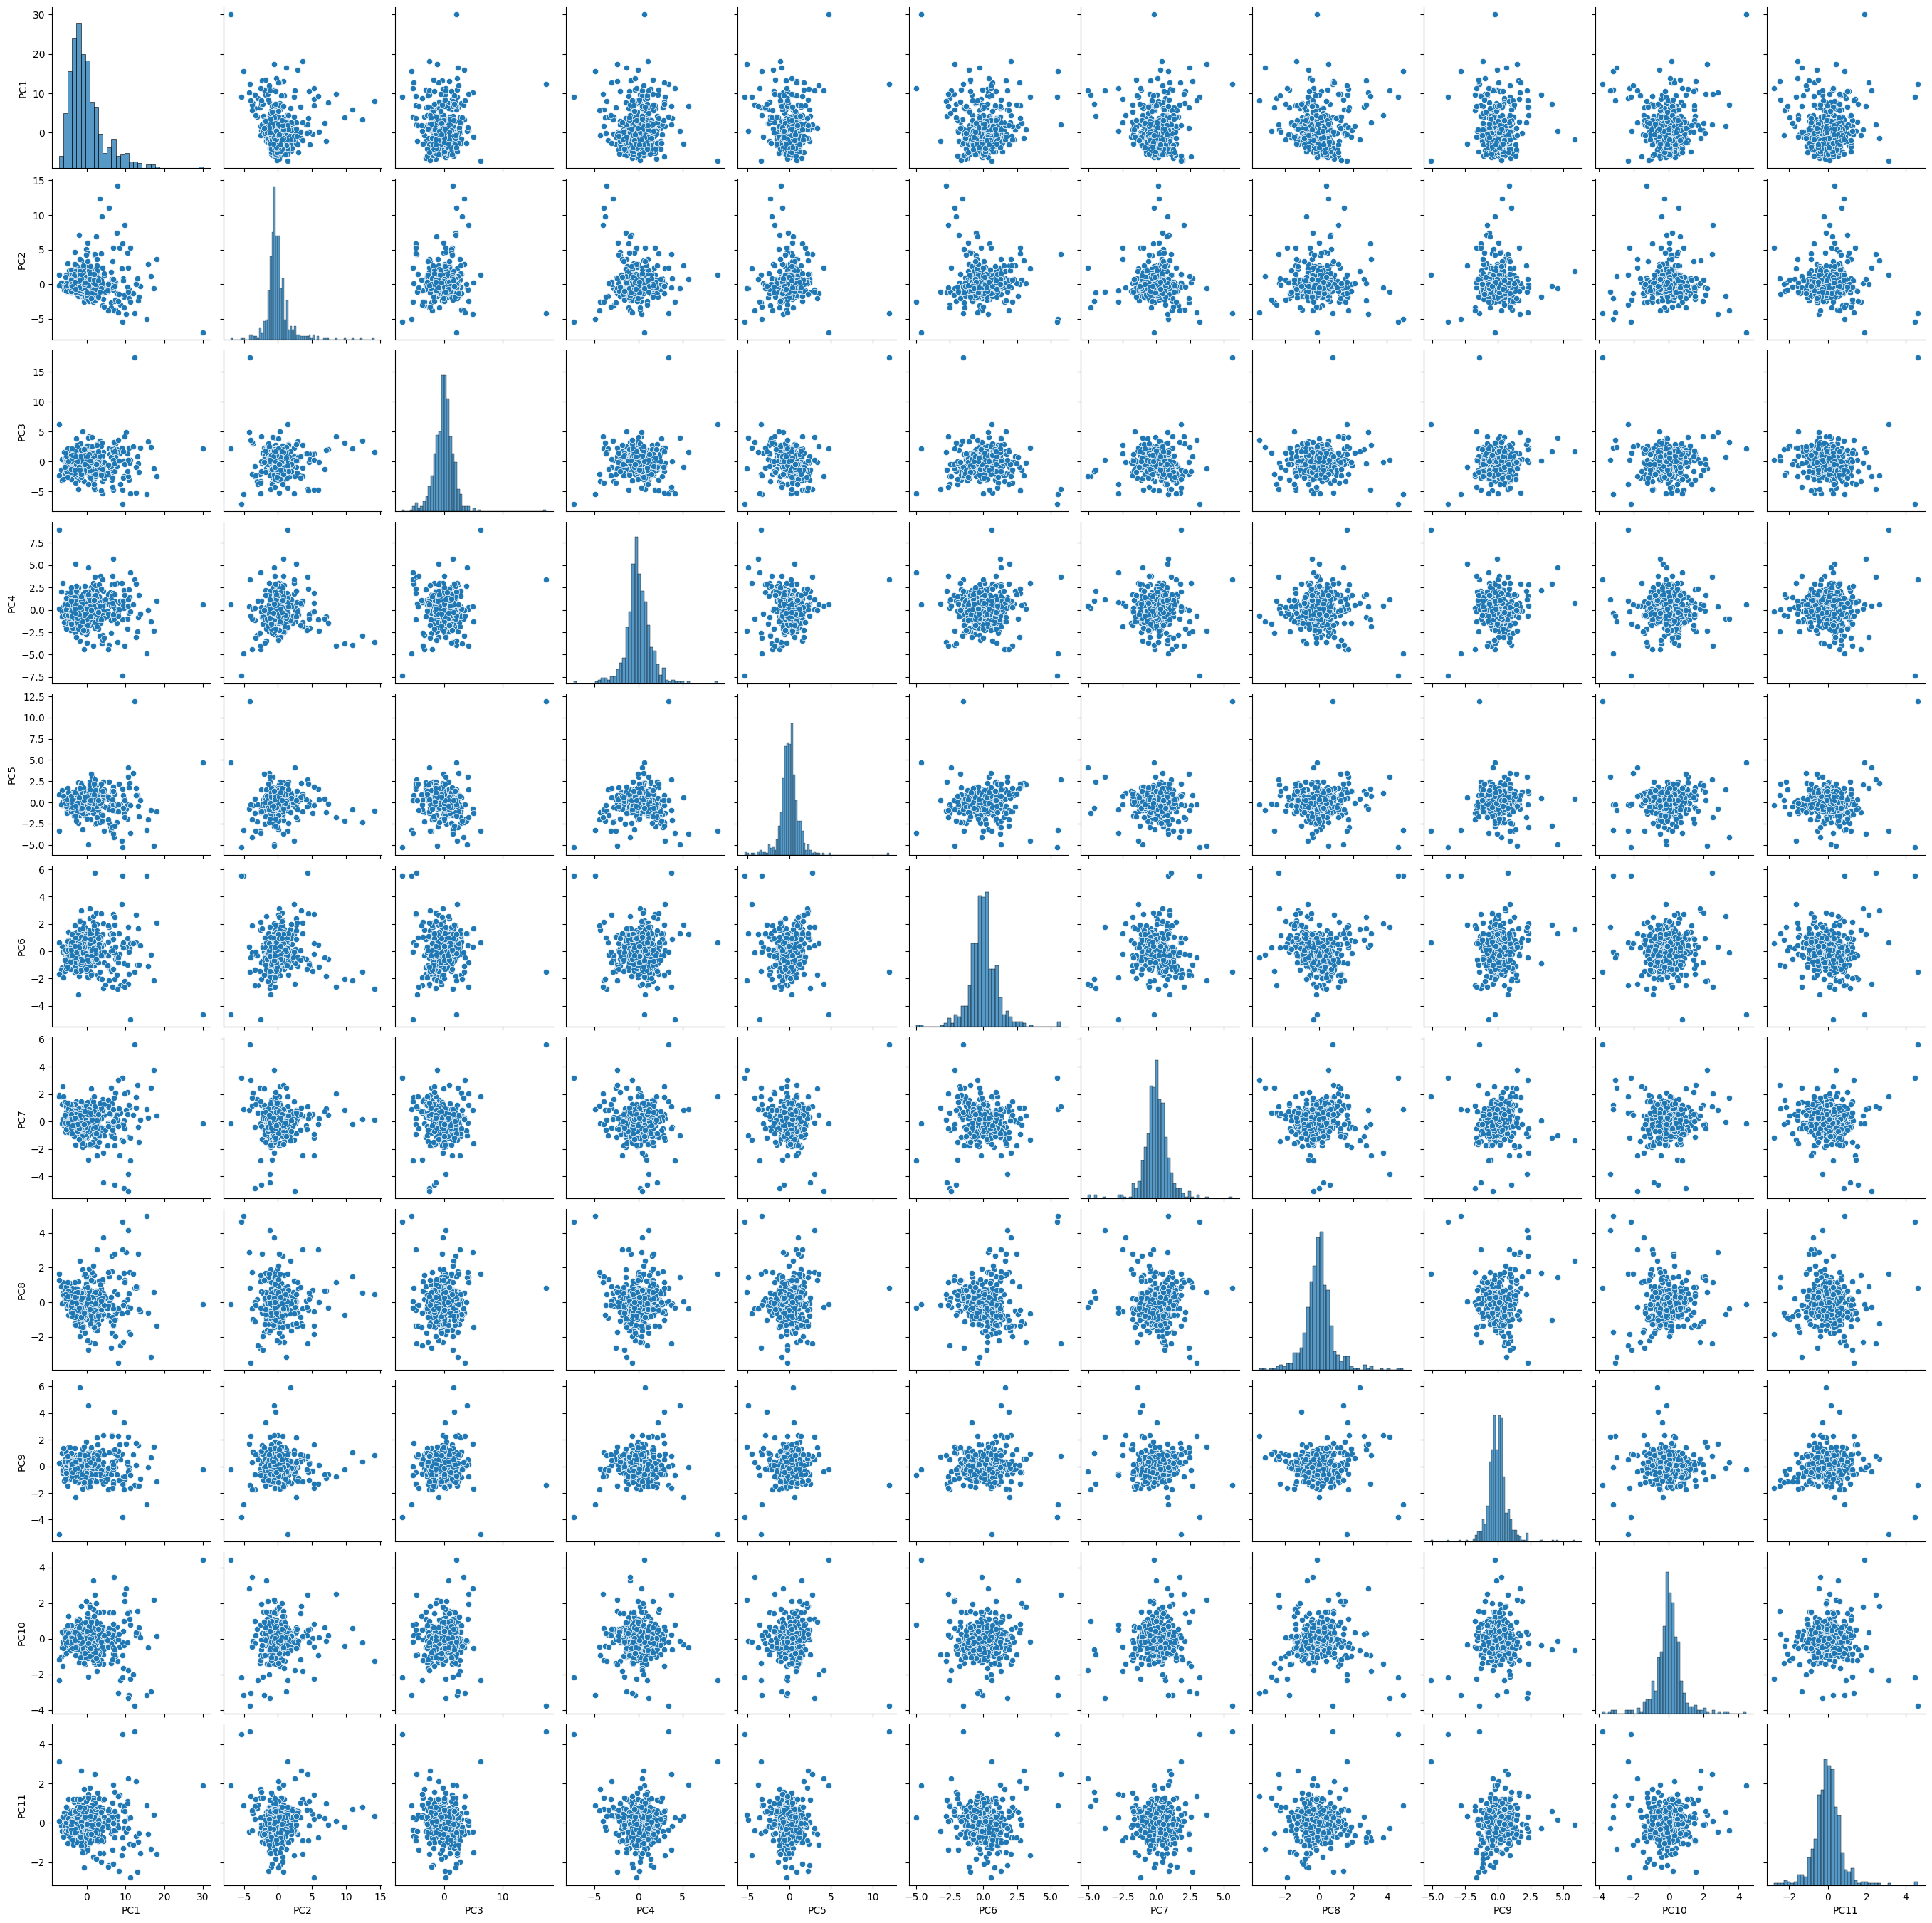

In [ ]:
## scatter plot por pares de componentes principales
sns.pairplot(df_clustering_pca)
plt.show()



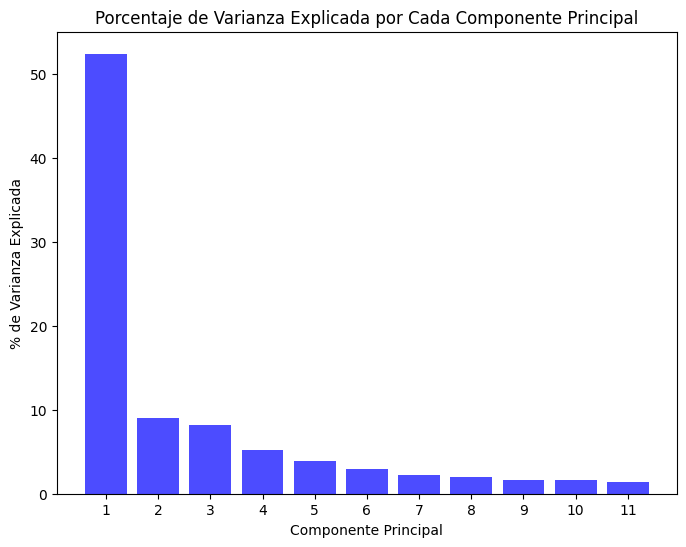

In [ ]:
pca_model = pipeline.named_steps['pca']

# 1. Graficar el porcentaje de varianza explicada por cada componente
plt.figure(figsize=(8, 6))
plt.bar(np.arange(1, pca_model.n_components_ + 1), pca_model.explained_variance_ratio_ * 100, alpha=0.7, color='b')

# Etiquetas y título
plt.title('Porcentaje de Varianza Explicada por Cada Componente Principal')
plt.xlabel('Componente Principal')
plt.ylabel('% de Varianza Explicada')
plt.xticks(np.arange(1, pca_model.n_components_ + 1))  
plt.show()

## Modelado con KMeans

In [ ]:
def evaluate_kmeans(X, weights, k_values):
    silhouette_scores = []

    for k in k_values:
        # Pasar sample_weight al método fit
        kmeans = KMeans(n_clusters=k, random_state=42, max_iter=10000)
        labels = kmeans.fit_predict(X, sample_weight=weights)
        score = silhouette_score(X, labels)
        silhouette_scores.append(score)

        # Generar gráfico de silueta
        plot_silhouette(X, labels, k)

    return silhouette_scores



# Función para graficar el diagrama de silueta
def plot_silhouette(X, labels, k):
    silhouette_vals = silhouette_samples(X, labels)
    y_lower, y_upper = 0, 0
    n_clusters = np.unique(labels).shape[0]
    plt.figure(figsize=(7, 5))

    for i in range(n_clusters):
        ith_cluster_silhouette_values = silhouette_vals[labels == i]
        ith_cluster_silhouette_values.sort()
        y_upper += len(ith_cluster_silhouette_values)
        color = cm.nipy_spectral(float(i) / n_clusters)
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color, edgecolor=color, alpha=0.7)
        y_lower = y_upper

    plt.axvline(x=np.mean(silhouette_vals), color="red", linestyle="--")
    plt.title(f'Silhouette plot for {k} clusters')
    plt.xlabel('Silhouette coefficient values')
    plt.ylabel('Cluster labels')
    plt.tight_layout()
    plt.show()

# Función para graficar silhouette score en función de k
def plot_silhouette_vs_k(k_values, silhouette_scores):
    plt.figure(figsize=(8, 6))
    plt.plot(k_values, silhouette_scores, marker='o', linestyle='-', color='b')
    plt.title('Silhouette Score vs Number of Clusters (k)')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    plt.show()


# Función para graficar los centroides en un gráfico radial
def plot_centroid_radar(centroids, k):
    num_features = centroids.shape[1]
    angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
    angles += angles[:1]  # Cerrar el círculo

    plt.figure(figsize=(8, 8))
    
    for i in range(centroids.shape[0]):
        values = centroids[i].tolist()
        values += values[:1]  # Cerrar el círculo para el gráfico
        plt.subplot(1, 1, 1)
        plt.fill(angles, values, alpha=0.25)
        plt.plot(angles, values, label=f'Cluster {i + 1}')

    plt.xticks(angles[:-1], [f'Feature {i + 1}' for i in range(num_features)])
    plt.title(f'Centroid Radar Plot for {k} Clusters')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    
def plot_centroid_spider_plotly(centroids, k):
    # Crear un DataFrame con los centroides
    num_features = centroids.shape[1]
    feature_labels = [f'Feature {i + 1}' for i in range(num_features)]
    
    # Preparar los datos para Plotly
    data = []
    for i in range(k):
        values = centroids[i].tolist() + [centroids[i][0]]  # Cerrar el círculo
        data.append(values)
    
    # Crear un DataFrame
    df = pd.DataFrame(data, columns=feature_labels + ['Feature 1'])
    df['Cluster'] = [f'Cluster {i + 1}' for i in range(k)]
    df = pd.melt(df, id_vars='Cluster', value_vars=feature_labels, var_name='Feature', value_name='Value')

    # Gráfico de araña (radar)
    fig = px.line_polar(df, r='Value', theta='Feature', color='Cluster', line_close=True,
                         title=f'Spider Plot for {k} Clusters')
    
    fig.update_traces(fill='toself', opacity=0.25)  # Rellenar el área
    fig.show()

# Ejemplo de uso
# Supongamos que tienes los centroides de 3 clusters con 4 características
centroids = np.array([[1, 2, 3, 4],
                      [2, 3, 4, 5],
                      [3, 4, 5, 6]])



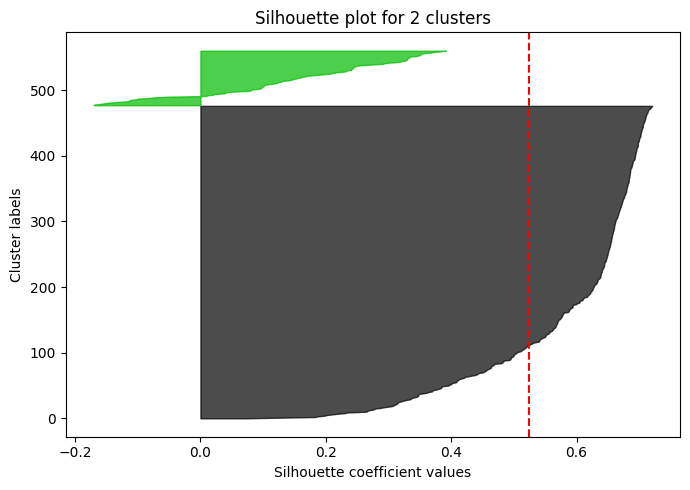

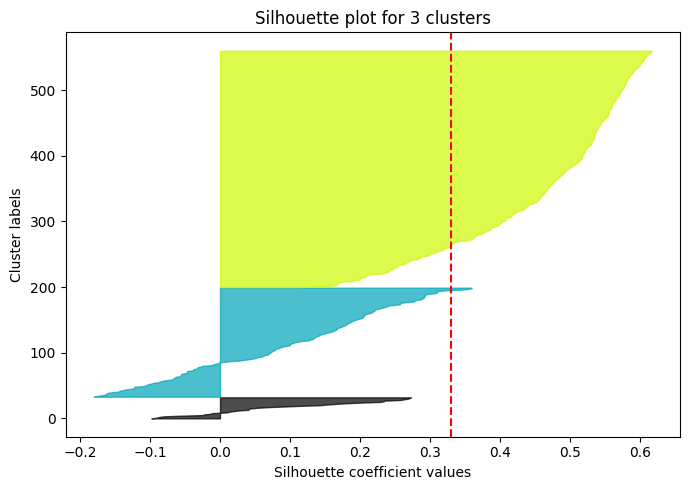

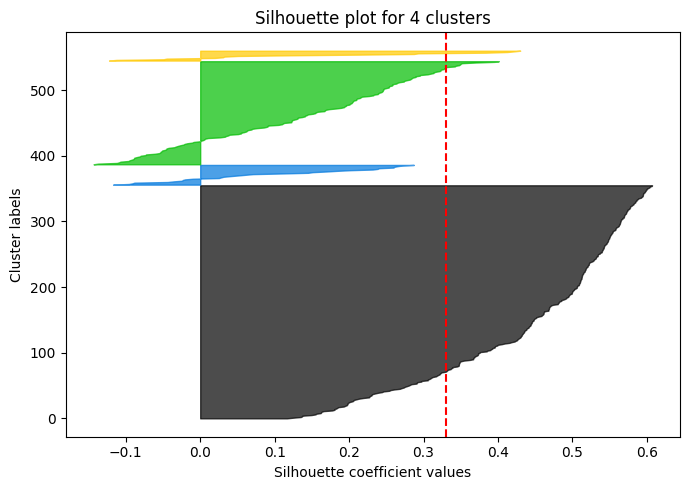

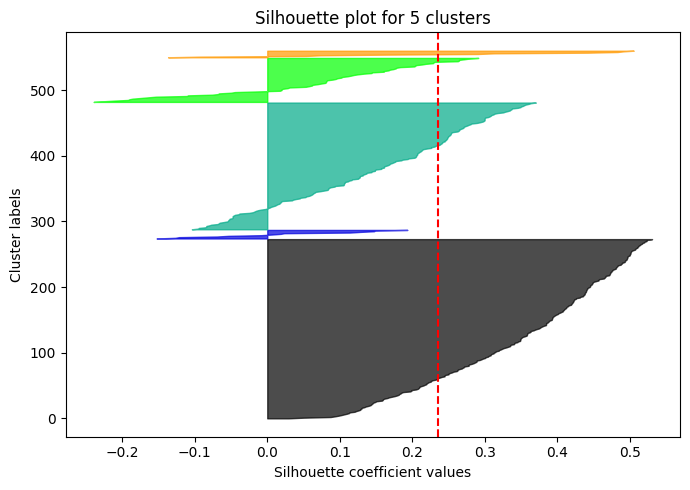

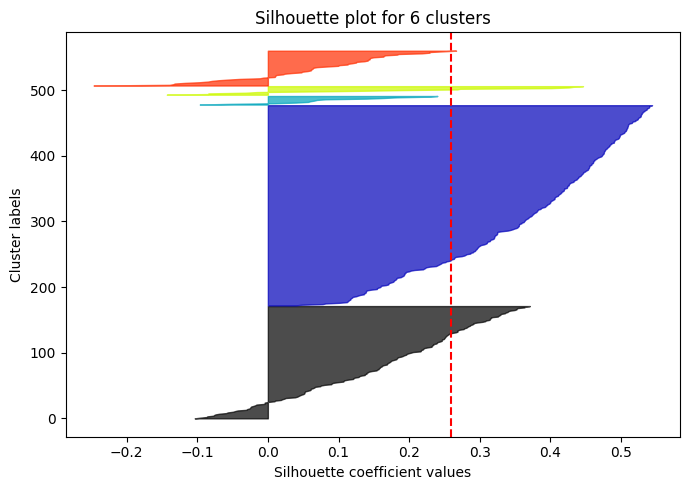

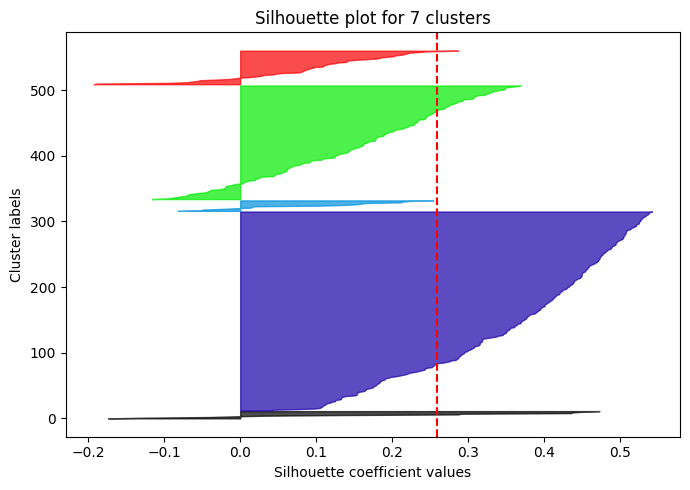

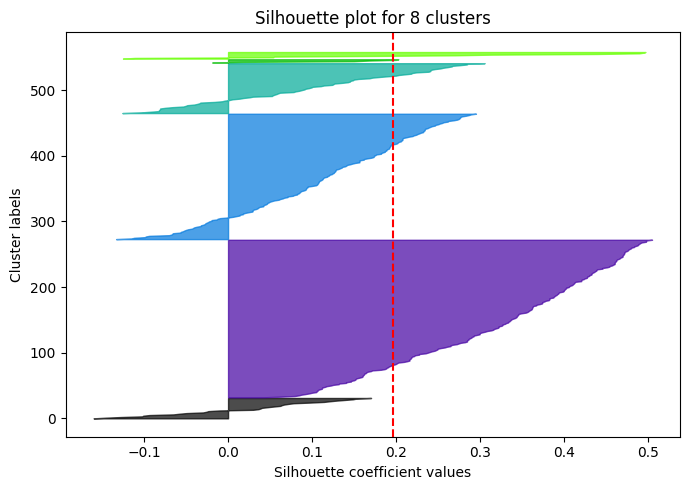

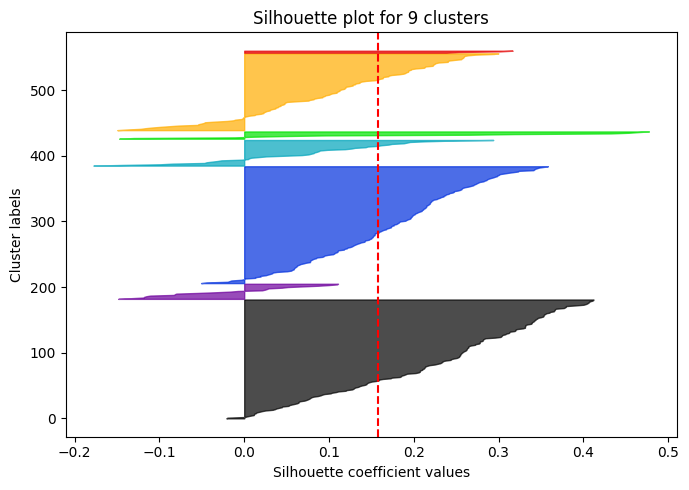

k = 2, Silhouette Score = 0.5248
k = 3, Silhouette Score = 0.3305
k = 4, Silhouette Score = 0.3296
k = 5, Silhouette Score = 0.2354
k = 6, Silhouette Score = 0.2598
k = 7, Silhouette Score = 0.2582
k = 8, Silhouette Score = 0.1959
k = 9, Silhouette Score = 0.1582


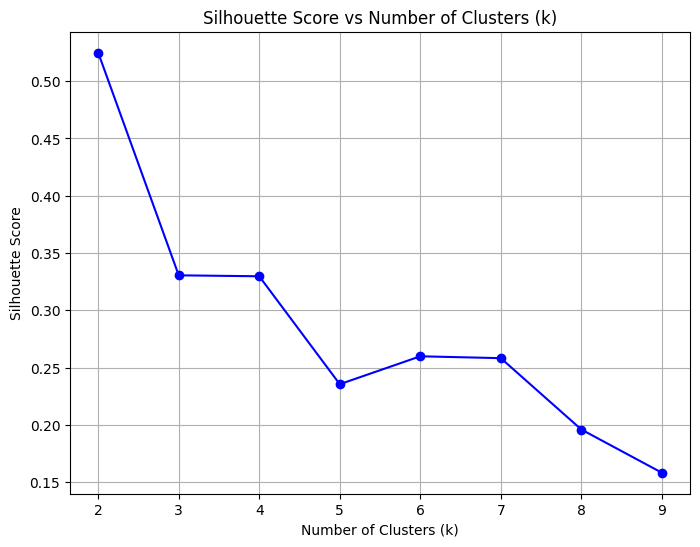

In [ ]:
k_values = range(2, 10)
weights = df_clustering['ponderador']
silhouette_scores = evaluate_kmeans(df_clustering_pca, weights,  k_values )
for k, score in zip(k_values, silhouette_scores):
    print(f'k = {k}, Silhouette Score = {score:.4f}')

    # Graficar silhouette score en función de k
plot_silhouette_vs_k(k_values, silhouette_scores)

In [ ]:
k=4
kmeans = KMeans(n_clusters=k, random_state=42, max_iter=10000)
labels = kmeans.fit_predict(df_clustering_pca, sample_weight=weights)

# Obtener los centroides
centroids = kmeans.cluster_centers_

# Graficar los centroides en un gráfico radial
plot_centroid_spider_plotly(centroids, 4)

Pendientes:

- En df_clustering incluir las otras columnas relacionadas con el consumo de nutrtientes que se creen para calcular los otros compomentes del dqi, por ejemplo el contenido de sal, la cantidad de tipos de proteina en promedio que consuma cada persona, etc.
- Analizar los resultados del proceso de PCA antes del clustering.
- Realizar tratamiento o eliminación de los valores atipicos en df_nutrients antes de correr todo el modelado


Agregado:
- Selección de variables con base en conocimiento del problema y alcance del análisis


Ideas:

- 

Notas corrida:
- En algunos archivos del catálogo los últimos dos campos no tienen etiqueta, se deben poner de manera manual en el Excel.